In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)

df = pd.read_parquet("../data/processed/youtube_sentiment.parquet")
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
df["comment_month"] = df["date"].dt.to_period("M")

print(f"Comentarios cargados: {len(df):,}")

Comentarios cargados: 62,989


In [2]:
# ============================================================
# BLOQUE 1 — Visión global del dataset
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)

# --- 1.1 Carga y verificación básica ---
df = pd.read_parquet("../data/processed/youtube_sentiment_v2.parquet")
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
df["comment_month"] = df["date"].dt.to_period("M")

print(f"Comentarios totales: {len(df):,}")
print(f"Vídeos únicos:       {df['video_id'].nunique():,}")
print(f"Canales únicos:      {df['channel'].nunique():,}")
print(f"Rango temporal:      {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nNulos por columna:\n{df.isnull().sum()}")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")

Comentarios totales: 62,989
Vídeos únicos:       372
Canales únicos:      248
Rango temporal:      2020-05-16 → 2026-03-07

Nulos por columna:
comment_id            0
video_id              0
text                  0
text_clean            0
likes                 0
date                  0
comment_year          0
author                1
reply_count           0
channel               0
published_at          0
query_used            0
video_viewCount       0
video_commentCount    0
video_duration_sec    0
n_palabras_clean      0
topic                 0
is_education          0
is_employment         0
period                0
sentiment_label       0
sentiment_score       0
comment_month         0
dataset_origen        0
fase                  0
sector_education      0
sector_employment     0
dtype: int64

Columnas disponibles:
['comment_id', 'video_id', 'text', 'text_clean', 'likes', 'date', 'comment_year', 'author', 'reply_count', 'channel', 'published_at', 'query_used', 'video_viewCount', 'video

In [3]:
# --- 1.2 Inspección de columnas clave ya calculadas ---

print("=== sentiment_label ===")
print(df["sentiment_label"].value_counts())

print("\n=== topic (primeros valores únicos) ===")
print(df["topic"].value_counts().head(10))

print("\n=== is_education ===")
print(df["is_education"].value_counts())

print("\n=== is_employment ===")
print(df["is_employment"].value_counts())

print("\n=== period ===")
print(df["period"].value_counts())

print("\n=== query_used (top 10) ===")
print(df["query_used"].value_counts().head(10))

=== sentiment_label ===
sentiment_label
negative    33341
neutral     16368
positive    13280
Name: count, dtype: int64

=== topic (primeros valores únicos) ===
topic
general       36895
education     10677
employment    10439
both           4978
Name: count, dtype: int64

=== is_education ===
is_education
False    47334
True     15655
Name: count, dtype: int64

=== is_employment ===
is_employment
False    47572
True     15417
Name: count, dtype: int64

=== period ===
period
2022-2026    35356
2020-2023    16581
2024         11052
Name: count, dtype: int64

=== query_used (top 10) ===
query_used
AI risks                        4225
AI and jobs future              3548
AI in education                 3413
AI taking jobs                  3360
AI ethics                       2846
AI benefits                     2770
ChatGPT                         2741
generative AI                   2636
artificial intelligence 2024    2631
AI taking jobs 2024             2591
Name: count, dtype: int64


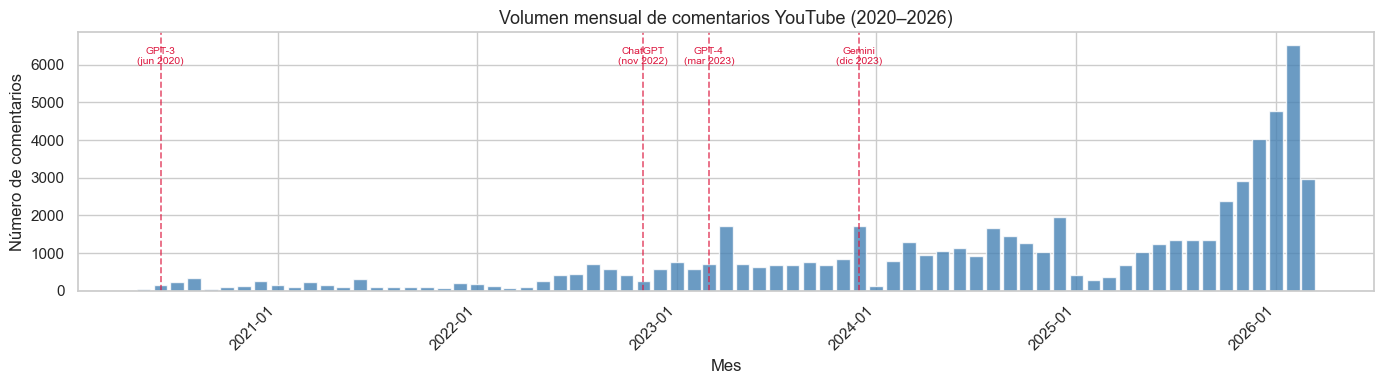


Meses con más comentarios:
comment_month
2026-02-01    6534
2026-01-01    4781
2025-12-01    4029
2026-03-01    2975
2025-11-01    2925
dtype: int64

Meses con menos comentarios (excluye extremos temporales):
comment_month
2020-09-01    45
2020-05-01    56
2022-03-01    72
2021-11-01    86
2021-10-01    90
dtype: int64


In [4]:
# --- 1.3 Distribución temporal del volumen de comentarios ---

fig, ax = plt.subplots(figsize=(14, 4))

volume = df.groupby("comment_month").size()
volume.index = volume.index.to_timestamp()

ax.bar(volume.index, volume.values, width=25, color="steelblue", alpha=0.8)

# Hitos clave
hitos = {
    "GPT-3\n(jun 2020)":    "2020-06-01",
    "ChatGPT\n(nov 2022)":  "2022-11-01",
    "GPT-4\n(mar 2023)":    "2023-03-01",
    "Gemini\n(dic 2023)":   "2023-12-01",
}
for label, fecha in hitos.items():
    ax.axvline(pd.Timestamp(fecha), color="crimson", linewidth=1.2, linestyle="--", alpha=0.7)
    ax.text(pd.Timestamp(fecha), volume.max() * 0.92, label,
            fontsize=7.5, color="crimson", ha="center")

ax.set_title("Volumen mensual de comentarios YouTube (2020–2026)", fontsize=13)
ax.set_xlabel("Mes")
ax.set_ylabel("Número de comentarios")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/01_volumen_mensual.png", dpi=150)
plt.show()

print(f"\nMeses con más comentarios:")
print(volume.sort_values(ascending=False).head(5))
print(f"\nMeses con menos comentarios (excluye extremos temporales):")
print(volume.sort_values().head(5))

La distribución temporal del corpus refleja el diseño de recolección, no la actividad real en YouTube. El crecimiento de comentarios en 2025–2026 se debe a que el dataset Post-2024 concentra más vídeos recientes. Este gráfico describe el corpus, no una tendencia de interés público.

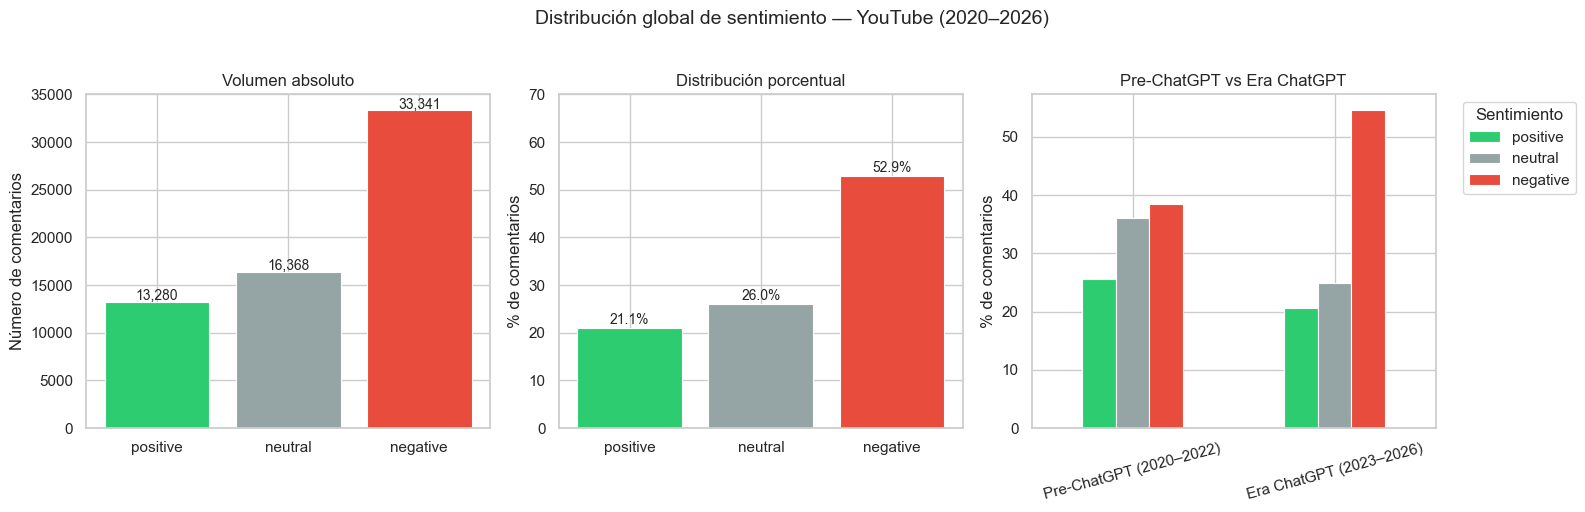

=== Distribución global ===
                     N     %
sentiment_label             
positive         13280  21.1
neutral          16368  26.0
negative         33341  52.9

=== Distribución por fase ===
sentiment_label          positive  neutral  negative
fase                                                
Pre-ChatGPT (2020–2022)      25.6     36.0      38.4
Era ChatGPT (2023–2026)      20.6     24.9      54.5

=== Comentarios por fase ===
fase
Era ChatGPT (2023–2026)    56679
Pre-ChatGPT (2020–2022)     6310
Name: count, dtype: int64


In [5]:
# ============================================================
# BLOQUE 2 — Distribución global de sentimiento
# ============================================================

# Paleta fija para sentimiento — úsala siempre igual en todo el TFG
SENTIMENT_COLORS = {
    "positive": "#2ecc71",
    "neutral":  "#95a5a6",
    "negative": "#e74c3c"
}
ORDER = ["positive", "neutral", "negative"]

# --- Asignar fase analítica basada en fecha real del comentario ---
df["fase"] = df["date"].apply(
    lambda d: "Pre-ChatGPT (2020–2022)" if pd.notnull(d) and d < pd.Timestamp("2022-11-01", tz="UTC")
              else "Era ChatGPT (2023–2026)"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución global de sentimiento — YouTube (2020–2026)", fontsize=14, y=1.02)

# --- 2.1 Conteos absolutos ---
counts = df["sentiment_label"].value_counts().reindex(ORDER)
axes[0].bar(ORDER, counts.values,
            color=[SENTIMENT_COLORS[s] for s in ORDER], edgecolor="white", linewidth=0.8)
axes[0].set_title("Volumen absoluto")
axes[0].set_ylabel("Número de comentarios")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

# --- 2.2 Porcentajes ---
pcts = df["sentiment_label"].value_counts(normalize=True).reindex(ORDER) * 100
axes[1].bar(ORDER, pcts.values,
            color=[SENTIMENT_COLORS[s] for s in ORDER], edgecolor="white", linewidth=0.8)
axes[1].set_title("Distribución porcentual")
axes[1].set_ylabel("% de comentarios")
axes[1].set_ylim(0, 70)
for i, v in enumerate(pcts.values):
    axes[1].text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)

# --- 2.3 Por fase analítica ---
FASES_ORDER = ["Pre-ChatGPT (2020–2022)", "Era ChatGPT (2023–2026)"]

pct_by_fase = (
    df.groupby(["fase", "sentiment_label"])
    .size()
    .unstack()
    .reindex(index=FASES_ORDER, columns=ORDER)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

pct_by_fase.plot(
    kind="bar",
    color=[SENTIMENT_COLORS[s] for s in ORDER],
    ax=axes[2],
    edgecolor="white",
    linewidth=0.8
)
axes[2].set_title("Pre-ChatGPT vs Era ChatGPT")
axes[2].set_ylabel("% de comentarios")
axes[2].set_xlabel("")
axes[2].legend(title="Sentimiento", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("../figures/02_distribucion_sentimiento.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Tabla resumen para la memoria ---
print("=== Distribución global ===")
resumen = pd.DataFrame({"N": counts, "%": pcts.round(1)})
print(resumen)

print("\n=== Distribución por fase ===")
print(pct_by_fase.round(1))

print("\n=== Comentarios por fase ===")
print(df["fase"].value_counts())

El corpus presenta una distribución de sentimiento mayoritariamente negativa (52.9%), frente a un 21.1% positivo y un 26.0% neutral. Al segmentar por fase temporal, se observa un incremento significativo de la negatividad entre la fase Pre-ChatGPT (38.4%) y la Era ChatGPT (54.5%), con una caída paralela de la positividad y la neutralidad. 

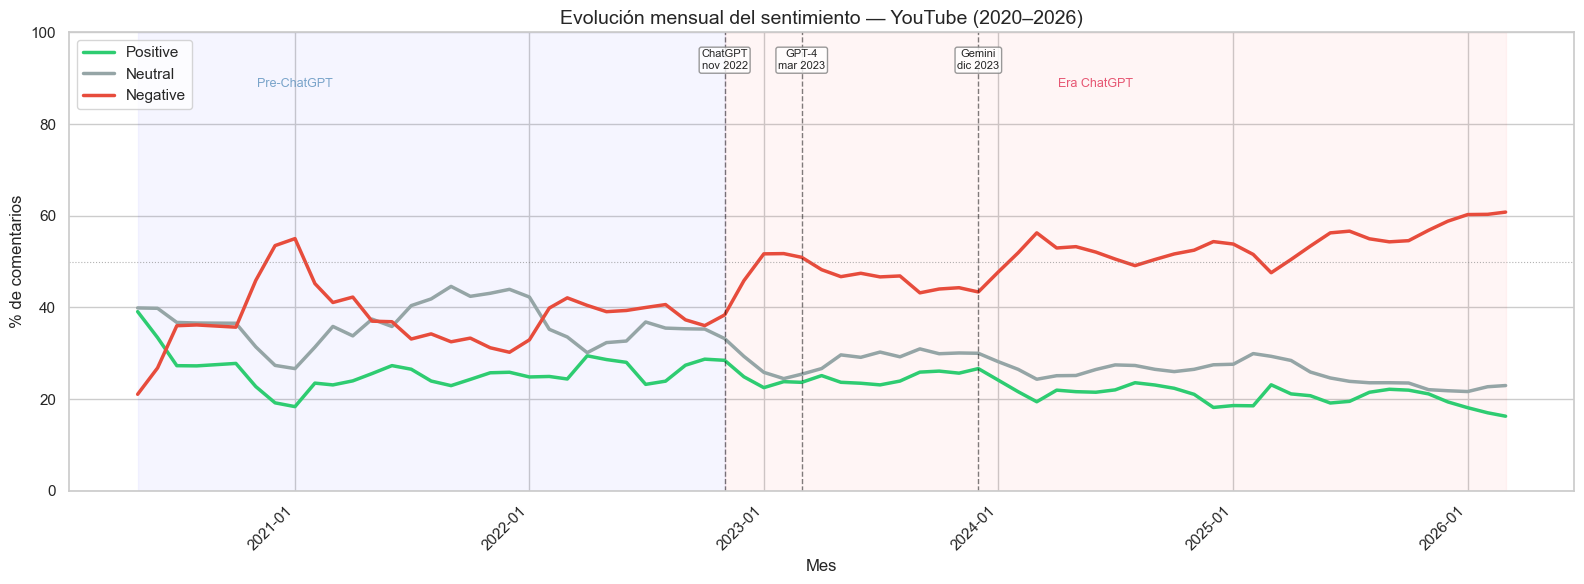

=== Media mensual de sentimiento por fase ===
sentiment_label  positive  neutral  negative
fase                                        
Era ChatGPT          22.0     26.6      51.3
Pre-ChatGPT          26.0     36.4      37.6


In [6]:
# ============================================================
# BLOQUE 3 — Evolución temporal del sentimiento
# ============================================================

# --- 3.1 Calcular % mensual por sentimiento ---
monthly = (
    df.groupby(["comment_month", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ORDER)
)

# Convertir a porcentaje fila a fila
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_pct.index = monthly_pct.index.to_timestamp()

# Filtrar meses con menos de 50 comentarios — poco fiables estadísticamente
monthly_counts = monthly.sum(axis=1)
monthly_counts.index = monthly_counts.index.to_timestamp()
monthly_pct = monthly_pct[monthly_counts >= 50]

# --- 3.2 Suavizado con media móvil de 3 meses ---
monthly_smooth = monthly_pct.rolling(window=3, center=True, min_periods=2).mean()

# --- 3.3 Gráfico ---
fig, ax = plt.subplots(figsize=(16, 6))

# Líneas suavizadas
for label in ORDER:
    ax.plot(monthly_smooth.index, monthly_smooth[label],
            color=SENTIMENT_COLORS[label], linewidth=2.5, label=label.capitalize())


# Línea de referencia al 50%
ax.axhline(50, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

# Hitos — líneas verticales anotadas
hitos = {
    "ChatGPT\nnov 2022":  "2022-11-01",
    "GPT-4\nmar 2023":    "2023-03-01",
    "Gemini\ndic 2023":   "2023-12-01",
}
for label, fecha in hitos.items():
    ts = pd.Timestamp(fecha)
    ax.axvline(ts, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
    ax.text(ts, 92, label, fontsize=8, ha="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="gray", alpha=0.8))

# Sombreado de fases
ax.axvspan(monthly_smooth.index.min(), pd.Timestamp("2022-11-01"),
           alpha=0.04, color="blue", label="_nolegend_")
ax.axvspan(pd.Timestamp("2022-11-01"), monthly_smooth.index.max(),
           alpha=0.04, color="red", label="_nolegend_")

# Etiquetas de fase
ax.text(pd.Timestamp("2021-01-01"), 88, "Pre-ChatGPT",
        fontsize=9, color="steelblue", alpha=0.7, ha="center")
ax.text(pd.Timestamp("2024-06-01"), 88, "Era ChatGPT",
        fontsize=9, color="crimson", alpha=0.7, ha="center")

ax.set_title("Evolución mensual del sentimiento — YouTube (2020–2026)", fontsize=14)
ax.set_ylabel("% de comentarios")
ax.set_xlabel("Mes")
ax.set_ylim(0, 100)
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/03_evolucion_temporal_sentimiento.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 3.4 Tabla de medias por fase para la memoria ---
df_monthly_fase = monthly_pct.copy()
df_monthly_fase["fase"] = df_monthly_fase.index.map(
    lambda d: "Pre-ChatGPT" if d < pd.Timestamp("2022-11-01") else "Era ChatGPT"
)
print("=== Media mensual de sentimiento por fase ===")
print(df_monthly_fase.groupby("fase")[ORDER].mean().round(1))

Canales con >= 100 comentarios: 170
Comentarios que representan: 59,680 (94.7% del corpus)


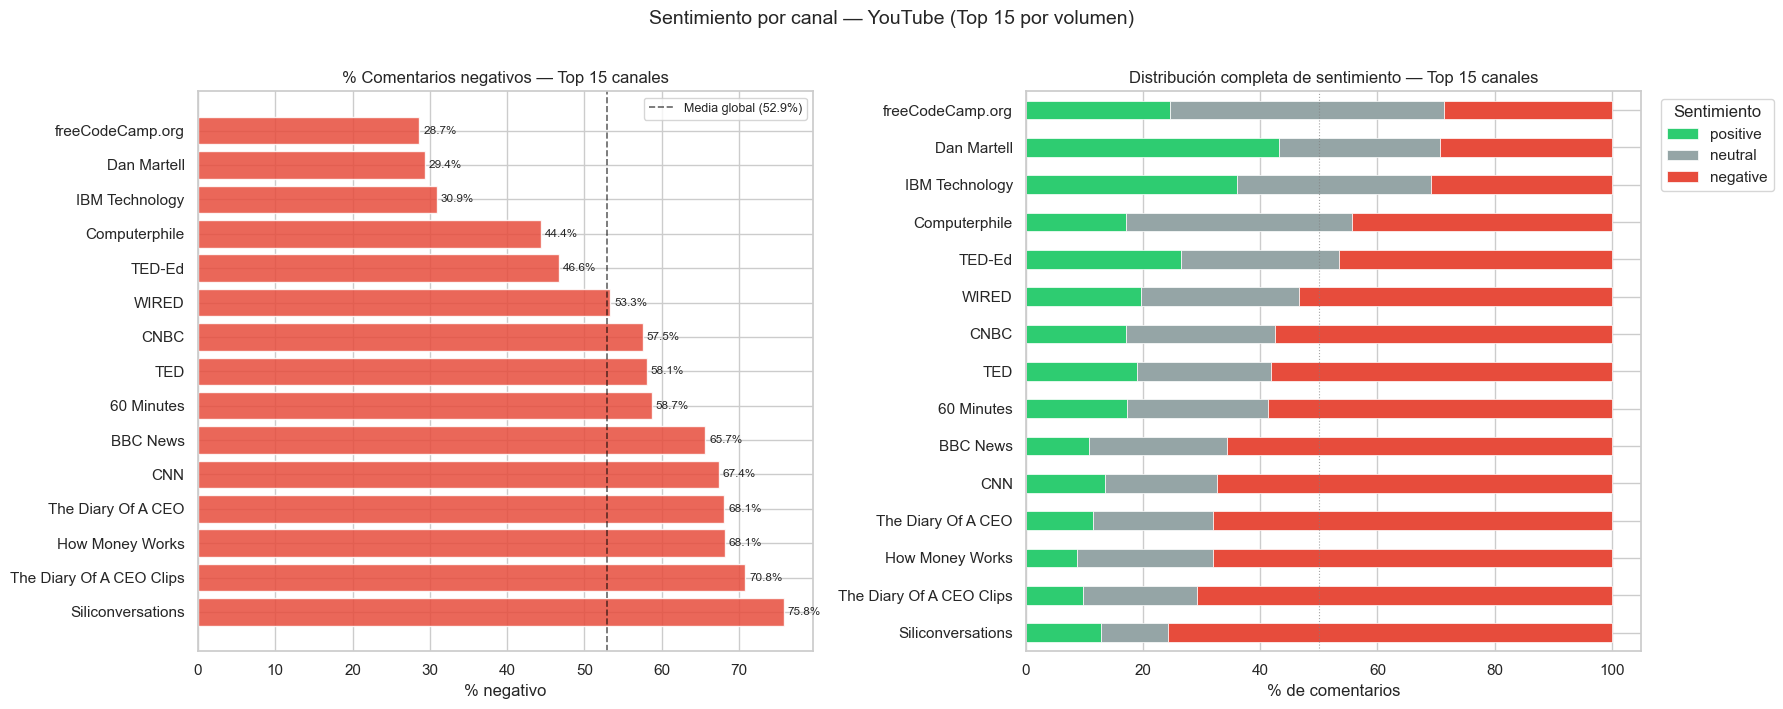


=== Tabla resumen por canal ===
sentiment_label           n_comentarios  positive  neutral  negative
channel                                                             
Siliconversations                   681      12.8     11.5      75.8
The Diary Of A CEO Clips            757       9.8     19.4      70.8
How Money Works                     847       8.7     23.1      68.1
The Diary Of A CEO                 1469      11.4     20.6      68.1
CNN                                 812      13.4     19.2      67.4
BBC News                           1115      10.7     23.7      65.7
60 Minutes                          802      17.2     24.1      58.7
TED                                2217      18.9     23.0      58.1
CNBC                               1069      17.1     25.4      57.5
WIRED                              1009      19.6     27.1      53.3
TED-Ed                              849      26.4     27.0      46.6
Computerphile                      1436      17.0     38.6      44.4
I

In [7]:
# ============================================================
# BLOQUE — Análisis de sentimiento por canal
# ============================================================

# Mínimo de comentarios para que el % sea fiable
MIN_COMENTARIOS_CANAL = 100

# Contar comentarios por canal y filtrar
canal_counts = df["channel"].value_counts()
canales_validos = canal_counts[canal_counts >= MIN_COMENTARIOS_CANAL].index

df_canales = df[df["channel"].isin(canales_validos)].copy()

print(f"Canales con >= {MIN_COMENTARIOS_CANAL} comentarios: {len(canales_validos)}")
print(f"Comentarios que representan: {len(df_canales):,} ({len(df_canales)/len(df)*100:.1f}% del corpus)")

# Distribución de sentimiento por canal
canal_sentiment = (
    df_canales.groupby(["channel", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ORDER)
)
canal_sentiment_pct = canal_sentiment.div(canal_sentiment.sum(axis=1), axis=0) * 100
canal_sentiment_pct["total"] = canal_counts

# Top 15 por volumen, ordenados por % negativo
top15 = canal_sentiment_pct.nlargest(15, "total").drop(columns="total")
top15_sorted = top15.sort_values("negative", ascending=False)

# ---- PARTE A: ranking por negatividad ----
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barras horizontales de % negativo
axes[0].barh(
    top15_sorted.index,
    top15_sorted["negative"],
    color=SENTIMENT_COLORS["negative"],
    alpha=0.85,
    edgecolor="white"
)
# Línea de referencia = media global
axes[0].axvline(
    pcts["negative"],
    color="black", linewidth=1.2,
    linestyle="--", alpha=0.6,
    label=f"Media global ({pcts['negative']:.1f}%)"
)
axes[0].set_title("% Comentarios negativos — Top 15 canales", fontsize=12)
axes[0].set_xlabel("% negativo")
axes[0].legend(fontsize=9)
# Añadir etiquetas
for i, (canal, row) in enumerate(top15_sorted.iterrows()):
    axes[0].text(row["negative"] + 0.5, i, f"{row['negative']:.1f}%",
                 va="center", fontsize=8.5)

# ---- PARTE B: distribución completa apilada ----
top15_sorted[ORDER].plot(
    kind="barh",
    stacked=True,
    color=[SENTIMENT_COLORS[s] for s in ORDER],
    ax=axes[1],
    edgecolor="white",
    linewidth=0.5
)
axes[1].set_title("Distribución completa de sentimiento — Top 15 canales", fontsize=12)
axes[1].set_xlabel("% de comentarios")
axes[1].set_ylabel("")
axes[1].legend(title="Sentimiento", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].axvline(50, color="gray", linewidth=0.8, linestyle=":", alpha=0.7)

plt.suptitle("Sentimiento por canal — YouTube (Top 15 por volumen)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/04_sentimiento_por_canal.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Tabla resumen ----
print("\n=== Tabla resumen por canal ===")
resumen_canales = top15_sorted.copy()
resumen_canales["n_comentarios"] = canal_counts[top15_sorted.index].astype(int)
print(resumen_canales[["n_comentarios"] + ORDER].round(1).to_string())

Grupo 1 — Medios de comunicación generalistas (60–76% negativo)
Siliconversations, The Diary of A CEO, CNN, BBC News, 60 Minutes. Son canales de noticias o entrevistas de alto impacto donde la IA se trata como tema de debate social, riesgo o controversia. El encuadre editorial es alarmista o crítico por naturaleza. The Diary of A CEO siendo tan negativo es interesante — es un canal de entrevistas a emprendedores donde la IA se discute en términos de amenaza al empleo y disrupcíón.

Grupo 2 — Divulgación tecnológica mainstream (44–58% negativo)
TED, CNBC, WIRED, 60 Minutes, TED-Ed. Están cerca de la media global o ligeramente por debajo. Tratan la IA con más matiz, ni puramente alarmistas ni puramente optimistas.

Grupo 3 — Canales técnicos o educativos (29–44% negativo)
Computerphile, IBM Technology, Dan Martell, freeCodeCamp. Aquí el perfil cambia radicalmente. Son canales donde la audiencia tiene conocimientos técnicos o está aprendiendo a usar IA. La percepción es mucho más positiva porque el encuadre es práctico y constructivo, no periodístico.


In [8]:
# ============================================================
# VALIDACIÓN CUALITATIVA — Muestra de comentarios por canal y sentimiento
# ============================================================

import random
random.seed(42)

# Canales representativos de cada grupo
canales_muestra = {
    "Muy negativo": "CNN",
    "Medio":        "TED",
    "Muy positivo": "Dan Martell"
}

n_por_sentimiento = 3  # comentarios por cada combinación canal x sentimiento

for grupo, canal in canales_muestra.items():
    print(f"\n{'='*70}")
    print(f"CANAL: {canal} ({grupo})")
    print(f"{'='*70}")
    
    df_canal = df[df["channel"] == canal]
    
    for sentimiento in ORDER:
        muestra = (
            df_canal[df_canal["sentiment_label"] == sentimiento]
            ["text"]
            .sample(n=min(n_por_sentimiento, len(df_canal[df_canal["sentiment_label"] == sentimiento])),
                    random_state=42)
            .tolist()
        )
        print(f"\n  --- {sentimiento.upper()} ---")
        for i, texto in enumerate(muestra, 1):
            # Truncar comentarios muy largos para legibilidad
            texto_corto = texto[:200] + "..." if len(texto) > 200 else texto
            print(f"  [{i}] {texto_corto}")


CANAL: CNN (Muy negativo)

  --- POSITIVE ---
  [1] Been using AICarma to monitor AI trends; it’s really helping me adapt my brand strategy.
  [2] The only thing that will impress me with AI is if it can eliminate evil
  [3] Bill Gates always brings thoughtful insights on AI’s impact, especially on how it can help developing countries. Definitely worth a watch for anyone curious about AI’s future!

Want to stay updated on...

  --- NEUTRAL ---
  [1] Well,  reporting the news weather can be done by Ai.... so you will be out a job  lol
  [2] SAI will have allegiance to nation but to itself. It doesn't matter if the US or China develops it first; eventually, those 2 Super AIs will align with each other because their goals are common.  They...
  [3] Their goal is to create a socialist economy where no one can own anything or even work hard to change it. Of course, this only matters if we let it. Vote with your wallets, People!

  --- NEGATIVE ---
  [1] Imagine if a person can trust with v

In [9]:
# Comprobación rápida
print(df[df["is_education"] == True]["query_used"].value_counts())
print("\n")
print(df[df["is_employment"] == True]["query_used"].value_counts())

query_used
AI in education                     2203
machine learning explained           870
AI replacing teachers                859
ChatGPT learning tool                795
ChatGPT students cheating            709
generative AI                        650
AI and jobs future                   629
AI benefits                          594
AI risks                             570
artificial intelligence 2024         567
AI taking jobs                       513
artificial intelligence school       489
AI explained                         463
AI ethics                            456
AI taking jobs 2024                  449
ChatGPT                              416
generative AI 2024                   398
artificial intelligence              367
AI for learning                      353
GPT-3 language model                 351
will AI replace workers              241
AI regulation                        224
artificial intelligence future       221
AI risks 2024                        221
artif

In [10]:
# ============================================================
# REASIGNACIÓN DE SECTORES CON LEMMATIZATION
# ============================================================

# Instalación (solo si no lo tienes)
# pip install spacy
# python -m spacy download en_core_web_sm

import spacy

# Cargar modelo de inglés
nlp = spacy.load("en_core_web_sm")

# Diccionarios en lemas — formas canónicas, no flexionadas
LEMAS_EDUCATION = {
    "student", "teacher", "school", "university", "college",
    "classroom", "homework", "education", "learn", "study",
    "academic", "curriculum", "professor", "tutor", "exam",
    "cheat", "plagiarism", "campus", "degree", "lecture",
    "teach", "course", "assignment", "grade", "knowledge"
}

LEMAS_EMPLOYMENT = {
    "job", "work", "worker", "employ", "unemploy", "layoff",
    "fire", "hire", "salary", "wage", "career", "profession",
    "automate", "replace", "workforce", "labor", "labour",
    "occupation", "income", "displacement", "redundant",
    "outsource", "resign", "retire", "strike", "union"
}

def contiene_lemas(texto, lemas_objetivo):
    """Lematiza el texto y comprueba si algún lema está en el diccionario."""
    doc = nlp(str(texto).lower()[:500])  # limitamos a 500 chars por velocidad
    lemas_texto = {token.lemma_ for token in doc if not token.is_stop and not token.is_punct}
    return bool(lemas_texto & lemas_objetivo)

# Aplicar — puede tardar 2-5 minutos sobre 62k comentarios
print("Procesando lemmatization... (puede tardar unos minutos)")

df["sector_education"] = df["text_clean"].apply(
    lambda t: contiene_lemas(t, LEMAS_EDUCATION)
)
df["sector_employment"] = df["text_clean"].apply(
    lambda t: contiene_lemas(t, LEMAS_EMPLOYMENT)
)

# Resumen
n_edu  = df["sector_education"].sum()
n_emp  = df["sector_employment"].sum()
n_both = (df["sector_education"] & df["sector_employment"]).sum()
n_none = (~df["sector_education"] & ~df["sector_employment"]).sum()

print("\n=== Distribución de sectores (lemmatization) ===")
print(f"Solo educación:    {n_edu - n_both:,}  ({(n_edu-n_both)/len(df)*100:.1f}%)")
print(f"Solo empleo:       {n_emp - n_both:,}  ({(n_emp-n_both)/len(df)*100:.1f}%)")
print(f"Ambos sectores:    {n_both:,}  ({n_both/len(df)*100:.1f}%)")
print(f"General (ninguno): {n_none:,}  ({n_none/len(df)*100:.1f}%)")
print(f"\nTotal corpus:      {len(df):,}")

ModuleNotFoundError: No module named 'spacy'

In [ ]:
# ============================================================
# VALIDACIÓN CUALITATIVA DE SECTORES
# ============================================================

print("=== MUESTRA EDUCACIÓN ===")
muestra_edu = (
    df[df["sector_education"] & ~df["sector_employment"]]
    ["text_clean"]
    .sample(8, random_state=42)
    .tolist()
)
for i, t in enumerate(muestra_edu, 1):
    print(f"[{i}] {t[:200]}")

print("\n=== MUESTRA EMPLEO ===")
muestra_emp = (
    df[df["sector_employment"] & ~df["sector_education"]]
    ["text_clean"]
    .sample(8, random_state=42)
    .tolist()
)
for i, t in enumerate(muestra_emp, 1):
    print(f"[{i}] {t[:200]}")

print("\n=== MUESTRA GENERAL (ningún sector) ===")
muestra_gen = (
    df[~df["sector_education"] & ~df["sector_employment"]]
    ["text_clean"]
    .sample(8, random_state=42)
    .tolist()
)
for i, t in enumerate(muestra_gen, 1):
    print(f"[{i}] {t[:200]}")

=== MUESTRA EDUCACIÓN ===
[1] I feel that even before the advent of AI, students often cheated because they did not care about what they were learning. If a teacher cannot adequately express why something is essential for a studen
[2] I don't get this copyright issue tbh. If you ask a talented artist, they can just as well create a picture in Picasso's style, it's not rocket science anymore, once the original artist came up with it
[3] The subject they learn at the beginning in lord of the flies and stuff my class just finished reading bro such a good book
[4] Now I am doing diploma in electrical engineering and I really want to learn industrial automation so what should I do after diploma for learning automation which course is best in automation and what'
[5] AI is here to stay whether you like it or not. so learn to live with it folks.
[6] Data Science pe ek course would be really appreciated sir!!
[7] Firstly, great advice, i have already done most of these steps so your advice fel

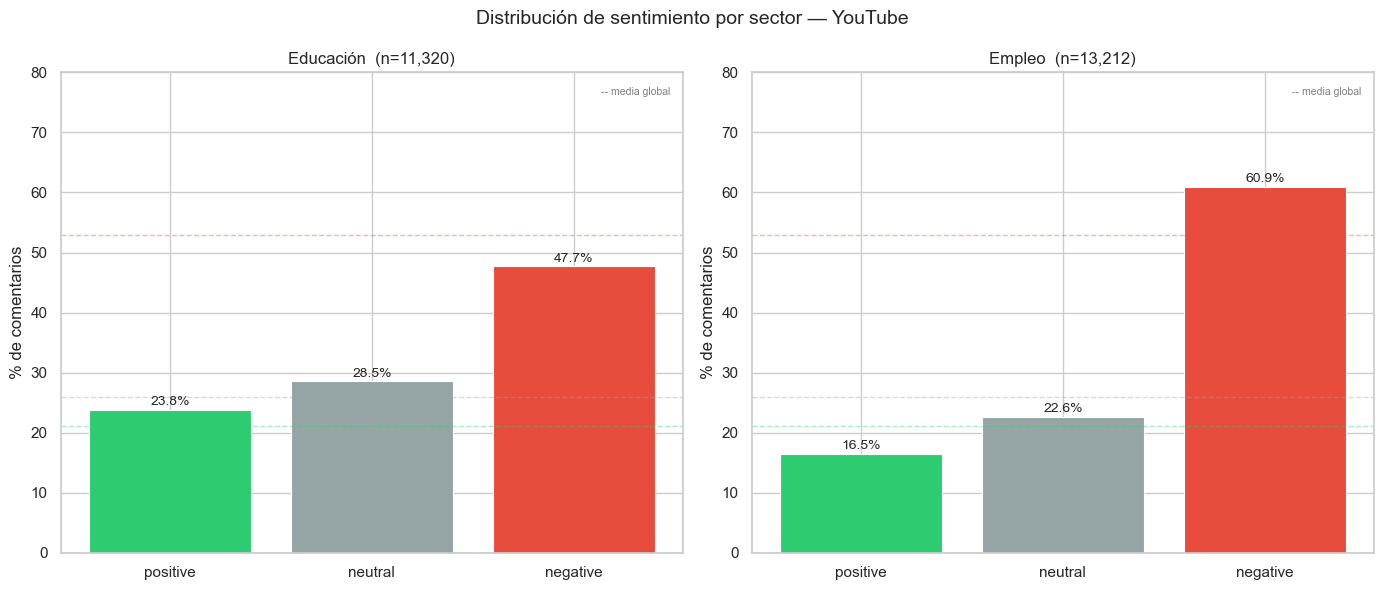

=== Sentimiento por sector ===

Educación (n=11,320)
  positive: 23.8%
  neutral: 28.5%
  negative: 47.7%

Empleo (n=13,212)
  positive: 16.5%
  neutral: 22.6%
  negative: 60.9%


In [ ]:
# ============================================================
# BLOQUE 4 — Análisis de sentimiento por sector
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distribución de sentimiento por sector — YouTube", fontsize=14)

sectores = {
    "Educación": df[df["sector_education"]],
    "Empleo":    df[df["sector_employment"]]
}

for ax, (nombre, subset) in zip(axes, sectores.items()):
    pct = (
        subset["sentiment_label"]
        .value_counts(normalize=True)
        .reindex(ORDER) * 100
    )
    bars = ax.bar(
        ORDER, pct.values,
        color=[SENTIMENT_COLORS[s] for s in ORDER],
        edgecolor="white", linewidth=0.8
    )
    # Línea de referencia global
    for s, val in zip(ORDER, [21.1, 26.0, 52.9]):
        ax.axhline(val, color=SENTIMENT_COLORS[s],
                   linewidth=1.0, linestyle="--", alpha=0.4)
    for i, v in enumerate(pct.values):
        ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)
    ax.set_title(f"{nombre}  (n={len(subset):,})", fontsize=12)
    ax.set_ylabel("% de comentarios")
    ax.set_ylim(0, 80)
    ax.text(0.98, 0.97, "-- media global", transform=ax.transAxes,
            fontsize=7.5, color="gray", ha="right", va="top")

plt.tight_layout()
plt.savefig("../figures/05_sentimiento_por_sector.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Sentimiento por sector ===")
for nombre, subset in sectores.items():
    pct = subset["sentiment_label"].value_counts(normalize=True).reindex(ORDER) * 100
    print(f"\n{nombre} (n={len(subset):,})")
    for s in ORDER:
        print(f"  {s}: {pct[s]:.1f}%")

El sector del empleo concentra la mayor negatividad del corpus (60.9%), superando en 8 puntos porcentuales la media global (52.9%) y en 13 puntos al sector educativo (47.7%). El sector educativo, en cambio, presenta una distribución más equilibrada, con mayor presencia de comentarios positivos (23.8% vs 16.5% en empleo) y neutrales (28.5% vs 22.6%). Este patrón es coherente con H2: la percepción de la IA no es homogénea entre sectores — el empleo concentra el miedo y la resistencia, mientras que la educación genera una respuesta más ambivalente, donde coexisten la preocupación y el reconocimiento del potencial.

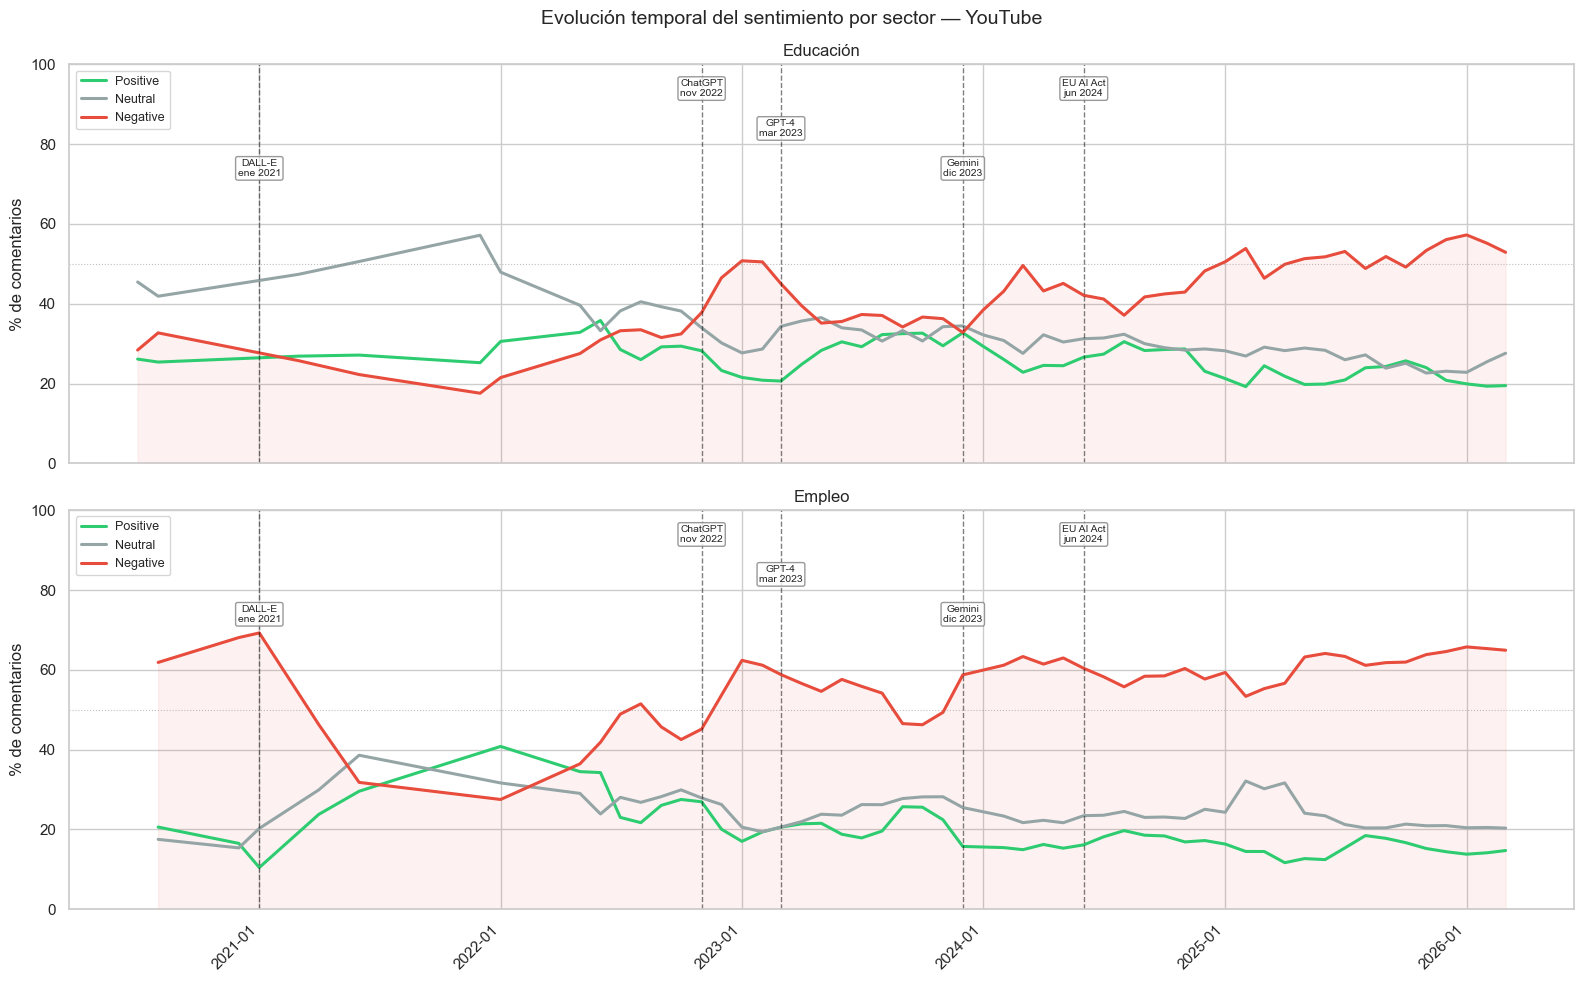

=== Media por fase y sector ===

Educación
  Pre-ChatGPT (n=903): neg=29.0% | pos=28.3%
  Era ChatGPT (n=10,417): neg=49.3% | pos=23.4%

Empleo
  Pre-ChatGPT (n=896): neg=46.8% | pos=24.6%
  Era ChatGPT (n=12,316): neg=61.9% | pos=15.9%


In [11]:
# ============================================================
# BLOQUE 4B — Evolución temporal por sector
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Evolución temporal del sentimiento por sector — YouTube", fontsize=14)

sectores = {
    "Educación": df[df["sector_education"]],
    "Empleo":    df[df["sector_employment"]]
}

# Hitos ordenados por fecha con posición vertical alternada para evitar solapamiento
HITOS = [
    ("2020-06-01", "GPT-3\njun 2020",        82),
    ("2021-01-01", "DALL-E\nene 2021",        72),
    ("2022-11-01", "ChatGPT\nnov 2022",       92),
    ("2023-03-01", "GPT-4\nmar 2023",         82),
    ("2023-12-01", "Gemini\ndic 2023",        72),
    ("2024-06-01", "EU AI Act\njun 2024",     92),
]

for ax, (nombre, subset) in zip(axes, sectores.items()):
    monthly = (
        subset.groupby(["comment_month", "sentiment_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=ORDER)
    )
    monthly_counts = monthly.sum(axis=1)
    monthly_pct = monthly.div(monthly_counts, axis=0) * 100
    monthly_pct.index = monthly_pct.index.to_timestamp()
    monthly_counts.index = monthly_counts.index.to_timestamp()

    # Filtrar meses con menos de 30 comentarios
    monthly_pct = monthly_pct[monthly_counts >= 30]

    # Suavizado 3 meses
    smooth = monthly_pct.rolling(window=3, center=True, min_periods=2).mean()

    for label in ORDER:
        ax.plot(smooth.index, smooth[label],
                color=SENTIMENT_COLORS[label],
                linewidth=2.2,
                label=label.capitalize())

    ax.fill_between(smooth.index, smooth["negative"],
                    alpha=0.07, color=SENTIMENT_COLORS["negative"])
    ax.axhline(50, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)

    # ── Hitos ────────────────────────────────────────────────
    fecha_min = smooth.index.min()
    fecha_max = smooth.index.max()

    for fecha_str, etiqueta, y_pos in HITOS:
        ts = pd.Timestamp(fecha_str)
        # Solo pintar el hito si cae dentro del rango de datos del subplot
        if ts < fecha_min or ts > fecha_max:
            continue
        ax.axvline(ts, color="black", linewidth=1.0, linestyle="--", alpha=0.5)
        ax.text(ts, y_pos, etiqueta,
                fontsize=7.5, ha="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          edgecolor="gray", alpha=0.8))

    ax.set_title(nombre, fontsize=12)
    ax.set_ylabel("% de comentarios")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left", fontsize=9)

axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/08_evolucion_temporal_sectores.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla resumen
print("=== Media por fase y sector ===")
for nombre, subset in sectores.items():
    print(f"\n{nombre}")
    for fase, fecha in [("Pre-ChatGPT", "<"), ("Era ChatGPT", ">=")]:
        if fecha == "<":
            sub = subset[subset["date"] < pd.Timestamp("2022-11-01", tz="UTC")]
        else:
            sub = subset[subset["date"] >= pd.Timestamp("2022-11-01", tz="UTC")]
        pct = sub["sentiment_label"].value_counts(normalize=True).reindex(ORDER) * 100
        print(f"  {fase} (n={len(sub):,}): neg={pct['negative']:.1f}% | pos={pct['positive']:.1f}%")

El análisis temporal por sector revela patrones cualitativamente distintos. En educación, la negatividad se duplica entre la fase Pre-ChatGPT (29.0%) y la Era ChatGPT (49.3%), partiendo además de una posición casi equilibrada con la positividad (28.3%). ChatGPT actúa aquí como punto de inflexión cualitativo: transforma un discurso previamente optimista en uno predominantemente crítico. En empleo, la negatividad era ya estructuralmente elevada antes de ChatGPT (46.8%) y se agrava hasta el 61.9% en la fase posterior, con una caída paralela de la positividad del 24.6% al 15.9%. En este sector ChatGPT no cambia la naturaleza del discurso sino que amplifica un miedo preexistente a la automatización y la pérdida de empleo.

In [ ]:
df.columns

Index(['comment_id', 'video_id', 'text', 'text_clean', 'likes', 'date',
       'comment_year', 'author', 'reply_count', 'channel', 'published_at',
       'query_used', 'video_viewCount', 'video_commentCount',
       'video_duration_sec', 'n_palabras_clean', 'topic', 'is_education',
       'is_employment', 'period', 'sentiment_label', 'sentiment_score',
       'comment_month', 'dataset_origen', 'fase', 'sector_education',
       'sector_employment'],
      dtype='object')

In [ ]:
df.to_parquet("../data/processed/youtube_sentiment_v2.parquet", index=False)
print("Guardado correctamente")
print(f"Columnas nuevas añadidas: fase, sector_education, sector_employment")

Guardado correctamente
Columnas nuevas añadidas: fase, sector_education, sector_employment
